In [69]:
import healpy as hp
import os
import matplotlib.pyplot as plt
from glob import glob

from matplotlib.colors import LinearSegmentedColormap

In [70]:
from numpy import log, sqrt, cos, pi
import numpy as np

import pylab
#from cratools import *

In [3]:
def SetupAbsThresholdColormap(amin, amax, threshold):
    """ Create a color map for "two-sided" thresholds.  Below the threshold,
        the map is a cool green-blue palette.  Between the lower and upper
        threshold, the map is gray-white-gray.  Above the upper threshold,
        the map is a warm red-yellow palette.
    """

    #t_min = amin if threshold>abs(amin) else -threshold
    #t_max = amax if threshold>amax else threshold

    x1 = (-threshold - amin) / (amax - amin)
    x3 = (amax - threshold) / (amax - amin)
    x2 = 1. - x1 - x3
    gvl = 0.5
    thrDict = {
        "red"    : ((0.0, 1.0, 0.5), (x1, 0.0, gvl), (x1 + 0.5*x2, 1.0, 1.0),
                    (x1 + x2, gvl, 0.7), (1.0, 1.0, 1.0)),
        "green"  : ((0.0, 1.0, 1.0), (x1, 0.0, gvl), (x1 + 0.5*x2, 1.0, 1.0),
                    (x1 + x2, gvl, 0.0), (1.0, 1.0, 1.0)),
        "blue"   : ((0.0, 1.0, 1.0), (x1, 0.7, gvl), (x1 + 0.5*x2, 1.0, 1.0),
                    (x1 + x2, gvl, 0.0), (1.0, 0.5, 1.0)) }
    return LinearSegmentedColormap("thresholdColormap", thrDict, 256)


def plot_map(skymap, title, label='', proj='C', dMin=None, dMax=None, filename=None, watermark='', 
             half_map=False, threshold=False, preliminary=False):

    #Colorway
    notext=True
    
    if proj=='C':
        rotation = (-180,0,0)
    else:
        rotation = (0,0,0)

    # Find min and max for unmasked pixels
    unmasked = np.array([i for i in skymap if (i!=hp.UNSEEN and i!=np.inf)])
    mmin = dMin if dMin!=None else unmasked.min()
    mmax = dMax if dMax!=None else unmasked.max()
    # In the case of a threshold outside of our range, set range to threshold
    if threshold:
        mmin = -threshold if mmin > -threshold else mmin
        mmax = threshold if mmax < threshold else mmax

    # Setup colormap with option for threshold
    colormap = plt.get_cmap('jet')
    if threshold:
        colormap = SetupAbsThresholdColormap(mmin, mmax, threshold)
    colormap.set_under('white')
    colormap.set_bad('gray')
    
    hp.mollview(skymap, 
            fig=1,
            title=title, 
            rot=rotation,coord=[proj],
            unit=label,
            notext=notext, cmap = colormap, min=dMin,max=dMax)

    fig = pylab.figure(1)
    for ax in fig.get_axes():
            if proj=='C0':
                ax.annotate("0$^\circ$", xy=(1.8, 0.625), size="x-large")
                ax.annotate("360$^\circ$",xy=(-1.95, 0.625), size="x-large")
            elif proj=='C':
                #ax.annotate("0$^\circ$", xy=(1.8, 0.625), size="x-large")
                #ax.annotate("360$^\circ$",xy=(-1.95, 0.625), size="x-large")
                if half_map:
                    ax.annotate("0$^\circ$", xy=(1.8, -0.625), size="x-large")
                    ax.annotate("360$^\circ$",xy=(-1.95, -0.625), size="x-large")
    
    hp.graticule()
    hp.projtext(95*degree+(rotation[0]-180)*degree, 280*degree-rotation[1]*degree,
                    watermark,
                    #coord=coords,
                    color="grey",
                    alpha=0.5,
                    rotation=0,
                    fontdict={"family":"sans-serif", "weight":"bold", "size":42})

    if preliminary:
        lParams = {'size':'xx-large','color':'white','family':'sans-serif','weight':'bold'}
        ax = [axis for axis in fig.get_axes() if type(axis) is hp.projaxes.HpxMollweideAxes][0]
        ax.annotate('IceCube Preliminary', xy=(0.5,-0.24), **lParams)
        ax.annotate(title, xy=(-1.85, -0.24), **lParams)
        ax.set_title(title, visible=False)
    
    if half_map:
        #ax = plt.pyplot.gca():
        plt.ylim([-1,0])
        
    if filename:
        fig.savefig(filename, bbox_inches='tight')

    plt.show()
    
    
def maskMap(map, decmin, decmax):
    degree = pi / 180.
    npix  = len(map) #not map.size?
    nside = hp.npix2nside(npix)
    theta, phi = hp.pix2ang(nside, range(npix))

    thetaMin = (90 - decmin) * degree
    thetaMax = (90 - decmax) * degree
    thetaCut = (theta <= thetaMin) * (theta >= thetaMax)

    new_map = np.copy(map) #not copy.deepcopy(map)?
    new_map[np.logical_not(thetaCut)] = hp.UNSEEN 

    return new_map

def smoothMap(m, wtsqr=False, norm=False, smooth_rad=0):

    if wtsqr==True:
        return None

    npix  = len(m)
    nside = hp.npix2nside(npix)
    #smooth_rad = opts['smooth'] * pi/180.
    smooth_map = np.zeros(npix)

    vec = np.transpose(hp.pix2vec(nside, np.arange(npix)))
    for i in range(npix):
        neighbors = hp.query_disc(nside, vec[i], smooth_rad)
        smooth_map[i] += m[neighbors].sum()
        if norm:
            smooth_map[i] /= (len(neighbors) + 1)

    return smooth_map

def TopHatSmooth(nside, origMap, radius, average=False):
    pixelList = []
    dsum = 0.0
    newmap = np.zeros(len(origMap))

    # Loop over all pixels
    for ipix in range(0, len(origMap)):
        # Ignore masked pixels
        if origMap[ipix] == hp.UNSEEN:
            newmap[ipix] = hp.UNSEEN
        else:
            theta,phi = hp.pix2ang(nside, ipix)
            center = hp.dir2vec(theta,phi)

            # Grab pixels with given angular radius of ith pixel
            pixelList = hp.query_disc(nside, center, radius)

            #Sum up pixels in the angular cap; set value of ith pixel to this sum
            dsum = 0.
            nsum = 0.
            for jpix in pixelList:
                if origMap[jpix] != hp.UNSEEN:
                   dsum += origMap[jpix]
                   nsum += 1.0

            if average and nsum>0:
                newmap[ipix] = dsum/nsum # set to average
            else:
                newmap[ipix] = dsum
    return newmap
    

In [4]:
#ROOT DIRECTORY
root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/@USER_DIR@'
out = '/home/@USER@/11-year-Update-Paper-Figures/skymaps/05_skymaps/output'

#This is where you pick what range of data you want to see. Note that this is in declination.
decMin=-90.0
decMax=-35.0 #-35 for sidereal, -40 for antisidereal

#this is used to decide how much smoothing is done
smoothAngle=20

nside = 64 #change to get from map as opposed to hard coding
degree = pi / 180

radius_smooth = smoothAngle * degree

In [60]:
title_code = {'tier1':'Energy Tier 1', 'tier2':'Energy Tier 2', 'tier3':'Energy Tier 3', 'tier4':'Energy Tier 4', 'nocuts':'No Tier Cuts'}
median_energies = {'tier1':300, 'tier2':900, 'tier3':2.3, 'tier4':6.6, 'nocuts':''}
energy_units = {'tier1':'TeV', 'tier2':'TeV', 'tier3':'PeV', 'tier4':'PeV', 'nocuts':''}
years = {'tier1':'2011-2014', 'tier2':'2011-2014', 'tier3':'2011-2021', 'tier4':'2011-2021', 'nocuts':'2011-2021'}

In [71]:
# Compare counts
tiers = ['tier1', 'tier2', 'tier3', 'tier4', 'nocuts']
for tier in tiers:
    print(tier)
    map_files = sorted(glob(f'{root}/{tier}/reconstruction/relintensityiter/combined*.fits.gz'))
    map_file = map_files[-1]
    #nocut_file = nocut_files[-1]
    data, bg, combined_llh_iter20 = hp.read_map(map_file, range(3))
    data1, bg1, combined_llh_iter20_ = hp.read_map(map_file, range(3))

    print(data.sum())
    #print(data1.sum())

tier1


IndexError: list index out of range

/tmp/ipykernel_3854/1213311797.py:16: RuntimeWarning: invalid value encountered in divide
  m = (data_smooth - bg_smooth) / bg_smooth


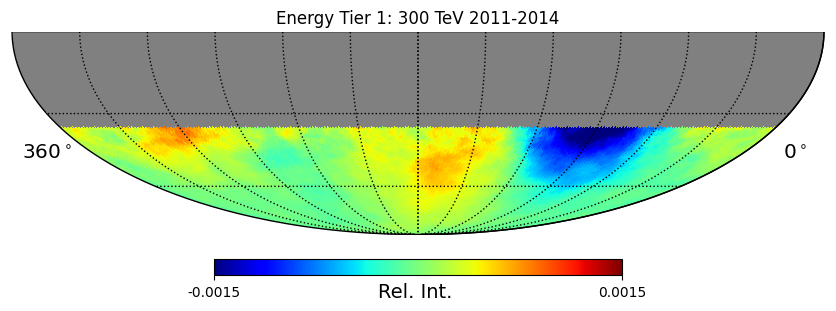

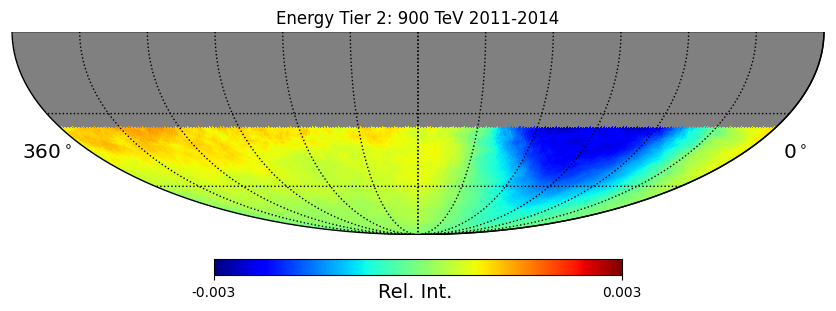

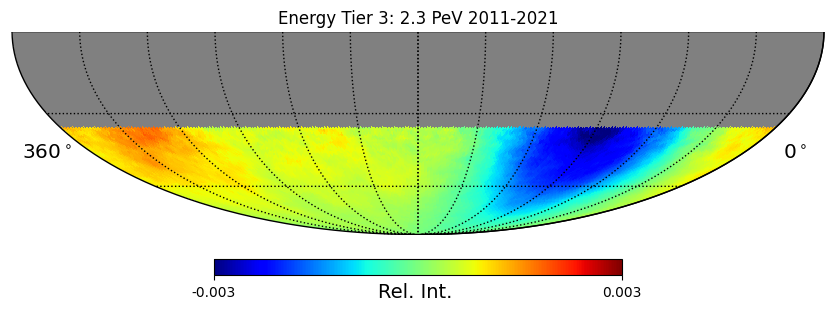

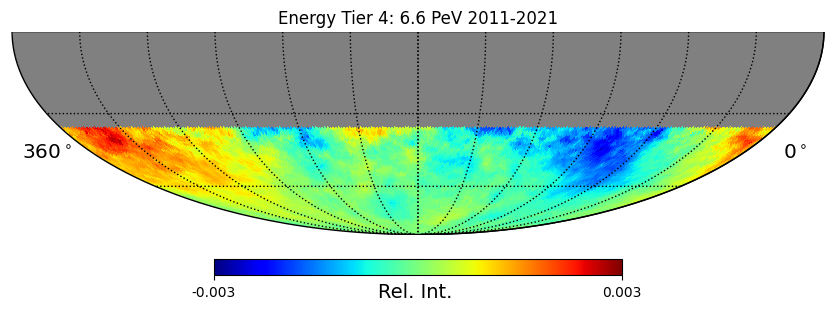

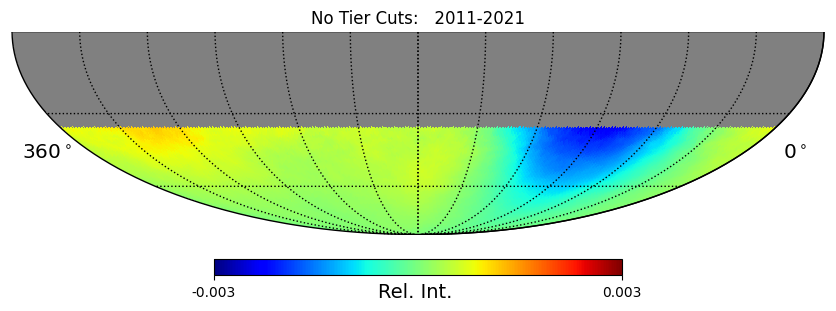

In [63]:
# Relative Intensity Plots

minmax = {'tier1':0.0015, 'tier2':0.003, 'tier3':0.003, 'tier4':0.003, 'nocuts':0.003}

for tier in tiers:

    map_files = sorted(glob(f'{root}/{tier}/reconstruction/relintensityiter/CR_IceTop__64_360_iteration*.fits.gz'))
    map_file = map_files[-1]
    data, bg, combined_llh_iter20 = hp.read_map(map_file, range(3))

    Title = f'{title_code[tier]}: {median_energies[tier]} {energy_units[tier]} {years[tier]}'
    
    #FRANKS METHOD
    data_smooth = smoothMap(data, smooth_rad=radius_smooth)
    bg_smooth = smoothMap(bg, smooth_rad=radius_smooth)
    m = (data_smooth - bg_smooth) / bg_smooth
    m[np.isnan(m)] = 0
    smoothed_map = maskMap(m, decMin, decMax)
    
    filename = f'{out}/{tier}_relint.png'
    plot_map(smoothed_map, Title, label="Rel. Int. ", half_map=True, 
             dMin=-minmax[tier], dMax=minmax[tier], filename=filename, preliminary=False)


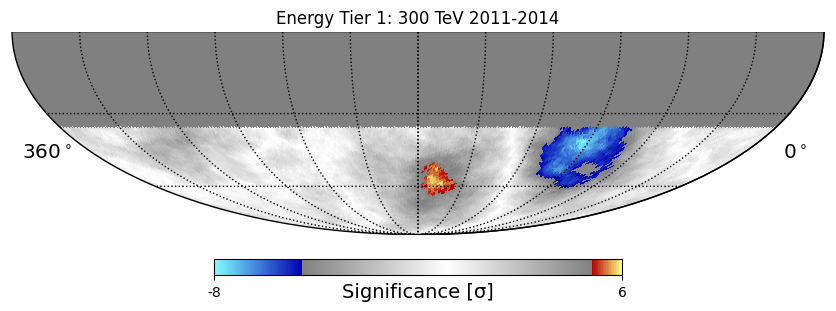

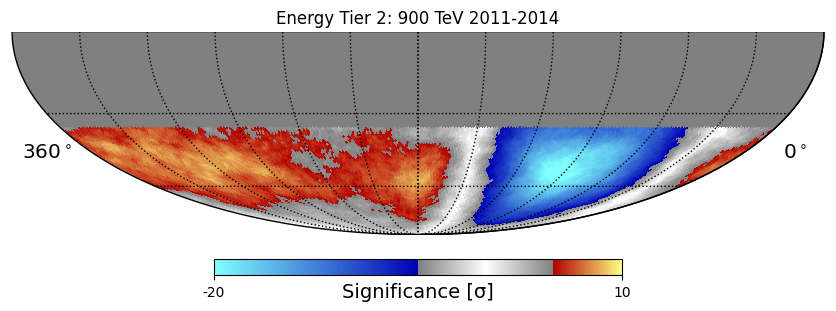

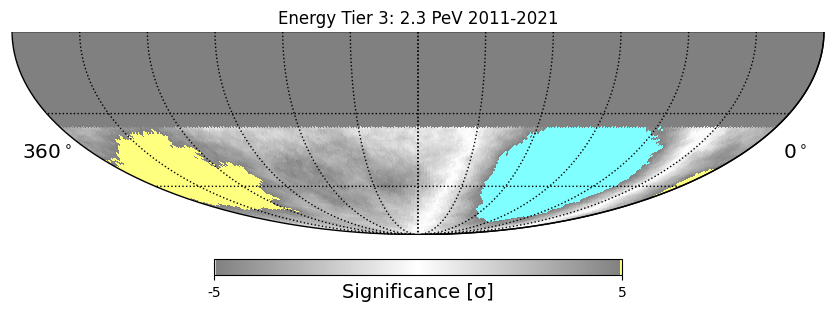

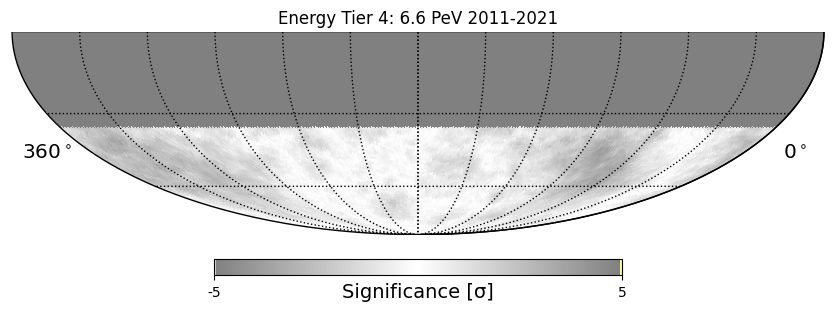

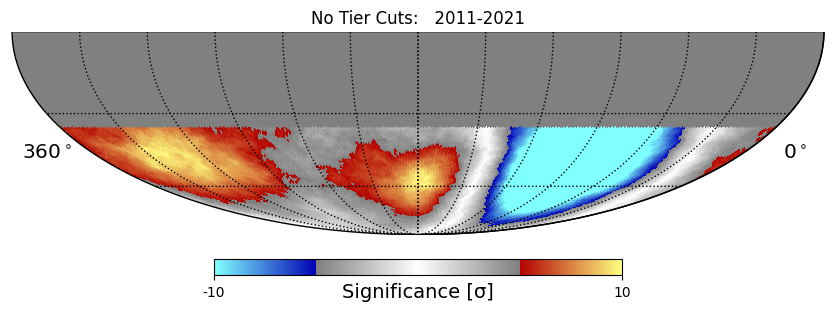

In [68]:
# Significance Plots

min_ = {'tier1':8, 'tier2':20, 'tier3':5, 'tier4':5, 'nocuts':10}
max_ = {'tier1':6, 'tier2':10, 'tier3':5, 'tier4':5, 'nocuts':10}

for tier in tiers:

    threshold = 3 if tier==4 else 5
    
    map_files = sorted(glob(f'{root}/{tier}/reconstruction/significanceiter/variance_IceTop__64_360_iteration*.fits.gz'))
    map_file = map_files[-1]
        
    variance_llh_iter20, sig, mean = hp.read_map(map_file, range(3))
    Title = f'{title_code[tier]}: {median_energies[tier]} {energy_units[tier]} {years[tier]}'
    #figure = plt.figure()
    #figure.text(0.3, 0.4, f'Threshold: {threshold}', fontname='sans-serif', fontsize='xx-large', color='white')
    #'size':'xx-large','color':'white','family':'sans-serif','weight':'bold')
    #Title = f'{median_energies[tier]} TeV'
        
    # Significance
    mask_sig = maskMap(sig, decMin, decMax)
    filename = f'{out}/{tier}_significance.png'
    plot_map(mask_sig, Title, label="Significance [σ]", half_map=True, 
             dMin=-min_[tier], dMax=max_[tier], filename=filename, threshold=threshold, preliminary=False)


In [ ]:
############## LEGACY CODE ##############

/tmp/ipykernel_518/3694823047.py:14: RuntimeWarning: invalid value encountered in divide
  m1 = (data_smooth1 - bg_smooth1) / bg_smooth1
/tmp/ipykernel_518/3694823047.py:27: RuntimeWarning: invalid value encountered in divide
  m2 = (data_smooth2 - bg_smooth2) / bg_smooth2
/tmp/ipykernel_518/3694823047.py:40: RuntimeWarning: invalid value encountered in divide
  m3 = (data_smooth3 - bg_smooth3) / bg_smooth3
/tmp/ipykernel_518/3694823047.py:53: RuntimeWarning: invalid value encountered in divide
  m4 = (data_smooth4 - bg_smooth4) / bg_smooth4


<Figure size 100x100 with 0 Axes>

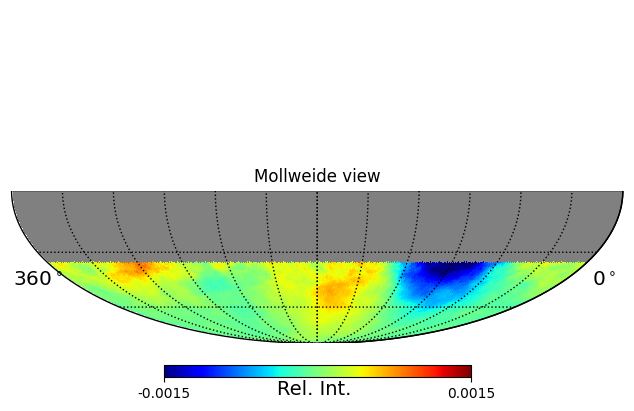

<Figure size 100x100 with 0 Axes>

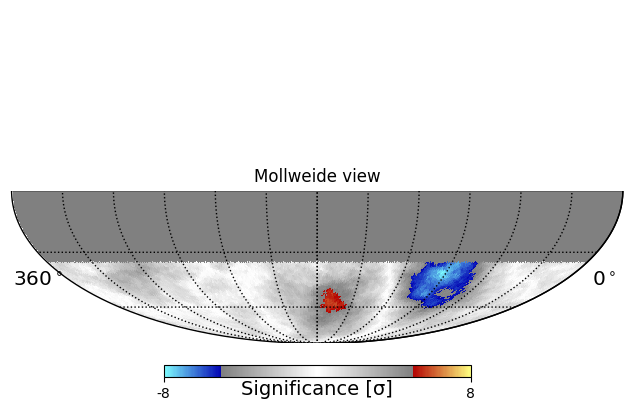

ValueError: x, y, and format string must not be None

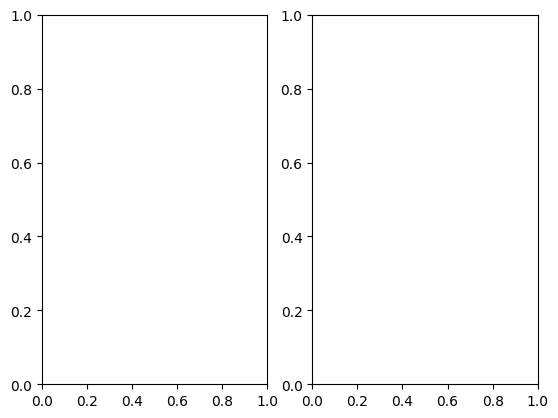

In [212]:
root = "/home/amcclure/cra_icetop_loyola/05_skymaps/output/"

#Tier 1
data1, bg1, combined_llh_iter201 = hp.read_map(root+"combined_t1_iteration04.fits.gz", [0, 1, 2])
variance_llh_iter201, sig1, mean1 = hp.read_map(root+"significance_t1_iteration04.fits.gz", [0, 1, 2])

Title1 = "Energy Tier 1: 310 TeV 2011-2014"
#Title = "No Energy Cuts Anti 2011-21"
#Relative Intensity

#FRANKS METHOD
data_smooth1 = smoothMap(data1, smooth_rad=radius_smooth)
bg_smooth1 = smoothMap(bg1, smooth_rad=radius_smooth)
m1 = (data_smooth1 - bg_smooth1) / bg_smooth1
m1[np.isnan(m1)] = 0
smoothed_map1 = maskMap(m1, decMin, decMax)
mask_sig1 = maskMap(sig1, decMin, decMax)


#Tier 2
data2, bg2, combined_llh_iter202 = hp.read_map(root+"combined_t2_iteration20.fits.gz", [0, 1, 2])
variance_llh_iter202, sig2, mean2 = hp.read_map(root+"significance_t2_iteration20.fits.gz", [0, 1, 2])
Title2 = "Energy Tier 2: 1.1 PeV 2011-2014"

data_smooth2 = smoothMap(data2, smooth_rad=radius_smooth)
bg_smooth2 = smoothMap(bg2, smooth_rad=radius_smooth)
m2 = (data_smooth2 - bg_smooth2) / bg_smooth2
m2[np.isnan(m2)] = 0
smoothed_map2 = maskMap(m2, decMin, decMax)
smoothed_map2 = maskMap(m2, decMin, decMax)
mask_sig2 = maskMap(sig2, decMin, decMax)

#Tier 3
data3, bg3, combined_llh_iter203 = hp.read_map(root+"combined_t3_iteration20.fits.gz", [0, 1, 2])
variance_llh_iter203, sig3, mean3 = hp.read_map(root+"significance_t3_iteration20.fits.gz", [0, 1, 2])
Title3 = "Energy Tier 3: 2.4 PeV 2011-2021"

data_smooth3 = smoothMap(data3, smooth_rad=radius_smooth)
bg_smooth3 = smoothMap(bg3, smooth_rad=radius_smooth)
m3 = (data_smooth3 - bg_smooth3) / bg_smooth3
m3[np.isnan(m3)] = 0
smoothed_map3 = maskMap(m3, decMin, decMax)
smoothed_map3 = maskMap(m3, decMin, decMax)
mask_sig3 = maskMap(sig3, decMin, decMax)

#Tier 4
data4, bg4, combined_llh_iter204 = hp.read_map(root+"combined_t4_iteration20.fits.gz", [0, 1, 2])
variance_llh_iter204, sig4, mean4 = hp.read_map(root+"significance_t4_iteration20.fits.gz", [0, 1, 2])
Title3 = "Energy Tier 4: 6.6 PeV 2011-2021"

data_smooth4 = smoothMap(data4, smooth_rad=radius_smooth)
bg_smooth4 = smoothMap(bg4, smooth_rad=radius_smooth)
m4 = (data_smooth4 - bg_smooth4) / bg_smooth4
m4[np.isnan(m4)] = 0
smoothed_map4 = maskMap(m4, decMin, decMax)
smoothed_map4 = maskMap(m4, decMin, decMax)
mask_sig4 = maskMap(sig4, decMin, decMax)


plt.subplot(1, 2, 1)
plt.axis('off')
fig1 = plt.figure(figsize=[1, 1])
sidtier1 = plot_map(smoothed_map1, Title1, label="Rel. Int. ", half_map=True , dMin = -.0015, dMax = .0015)
plt.subplot(1, 2, 2)
plt.axis('off')
fig1_ = plt.figure(figsize=[1,1])
sidtier1_ = plot_map(mask_sig1, Title1, label="Significance [σ]", half_map=True , threshold=5, dMin= -8, dMax = 8)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(sidtier1)
ax2.plot(sidtier1_)
#plt.subplot(4, 2, 3)
#plt.axis('off')
#sidtier2 = plot_map(smoothed_map2, Title2, label="Rel. Int.", half_map=True, dMin=-0.003, dMax=0.003)
#plt.subplot(4, 2, 4)
#plt.axis('off')
#sidtier2_ = plot_map(mask_sig2, Title2, label="Significance [σ]", half_map=True, threshold=5, dMin=-20, dMax=20)
#plt.subplot(4, 2, 5)
#plt.axis('off')
#sidtier3 = plot_map(smoothed_map3, Title3, label="Rel. Int.", half_map=True, dMin=-0.0025, dMax=0.0025)
#plt.subplot(4, 2, 6)
#plt.axis('off')
#sidtier3_ = plot_map(mask_sig3, Title3, label="Significance [σ]", half_map=True, threshold=5, dMin=-14, dMax=14)
#plt.subplot(4, 2, 7)
#plt.axis('off')
#sidtier4 = plot_map(smoothed_map4, Title4, label="Rel. Int.", half_map=True, dMin=-0.0035, dMax=0.0035)
#plt.subplot(4, 2, 8)
#plt.axis('off')
#sidtier4_ = plot_map(mask_sig4, Title4, label="Significance [σ]", half_map=True, threshold=3, dMin=-6, dMax=6)




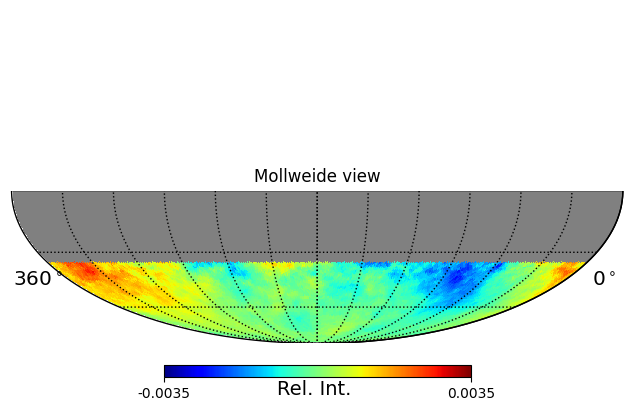

In [107]:
plt.axis('off')

fig1 = plt.subplot(1, 1, 1)
sidtier1 = plot_map(smoothed_map

fig4 = plt.subplot(4, 1, 1)
sidtier4 = plot_map(smoothed_map, title='6.6 PeV', label="Rel. Int. ", half_map=True, 
             dMin=-0.0035, dMax=0.0035, filename=filename, preliminary=False)
fig2 = plt.subplot(1,2,1)


In [79]:
# Legacy code

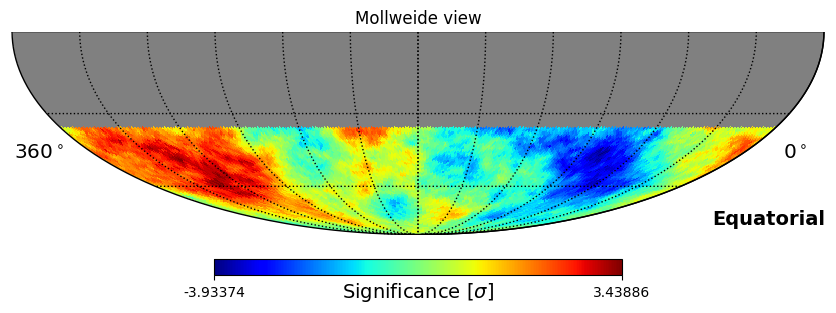

In [65]:
#SIGNIFICANCE

#FRANKS METHOD
data_smooth = smoothMap(data, smooth_rad=radius_smooth)
bg_smooth = smoothMap(bg, smooth_rad=radius_smooth)

with np.errstate(invalid='ignore', divide='ignore'):
    alpha = 1/20.
    #alpha = 1.
    # Allow for scaling term if weighted square maps necessary
    scale = 1.
    Non  = data_smooth * scale
    Noff = bg_smooth/alpha * scale

    sn = np.sign(data_smooth - bg_smooth)
    sigma = sn * sqrt(2*(Non*np.log(((1+alpha)*Non) / (alpha*(Non+Noff)))
                         + Noff * np.log(((1+alpha)*Noff) / (Non+Noff))))

sigma[np.isnan(sigma)] = 0
signed_significance = maskMap(sigma, decMin, decMax)
plot_map(signed_significance, Title, label='Significance [$\sigma$]', half_map=True) #, dMin=-3.5, dMax=3.5)

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


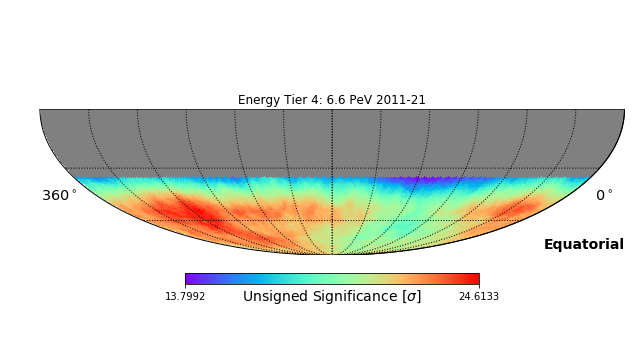

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()


0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


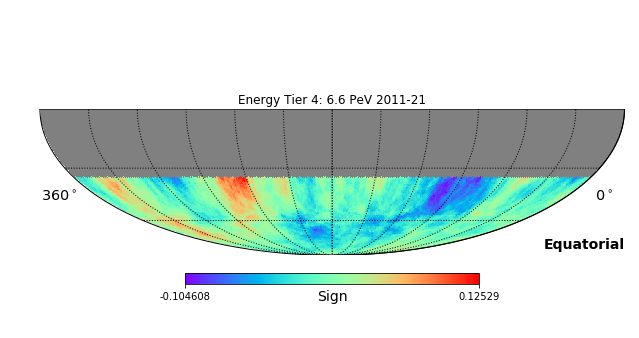

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


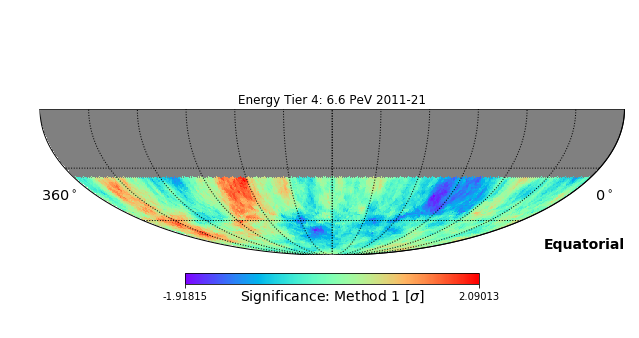

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


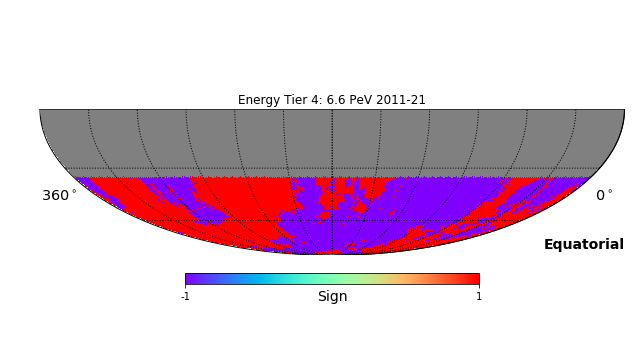

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


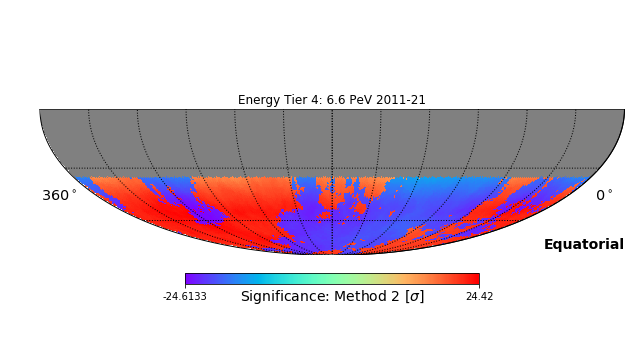

In [16]:
# SIGNIFICANCE SKYMAPS - JUAN CARLOS (MASK THEN SMOOTH) METHOD

# Unsigned significance
masked_variance = maskMap(sig, decMin, decMax)
variance_smooth = TopHatSmooth(nside, masked_variance, radius=radius_smooth, average=False) #Why is average false?
masked_np_variance_smooth = hp.ma(variance_smooth)
unsigned_significance = np.sqrt(np.abs(masked_np_variance_smooth))
plot_map(unsigned_significance, Title, label='Unsigned Significance [$\sigma$]', half_map=True)

# Calculating sign
rel_int = data/bg - 1
masked_combined = maskMap(rel_int, decMin, decMax)
num = TopHatSmooth(nside,masked_combined,radius=radius_smooth,average=True)


# Method used up till now:
abs_rel_int = np.abs(rel_int)
masked_denom = maskMap(abs_rel_int, decMin, decMax)
denom = TopHatSmooth(nside,masked_denom,radius=radius_smooth,average=True)
masked_np_num = hp.ma(num)
masked_np_denom = hp.ma(denom)
neg = masked_np_num / masked_np_denom
plot_map(neg, Title, label='Sign', half_map=True)

plot_map((unsigned_significance * neg).filled(fill_value=hp.UNSEEN), Title,
         label='Significance: Method 1 [$\sigma$]', half_map=True)

# Method where signs equals 1 (new attempt)
denom = np.abs(hp.ma(num))

masked_np_num = hp.ma(num)
masked_np_denom = hp.ma(denom)
neg_normalized = masked_np_num / masked_np_denom
plot_map(neg_normalized, Title, label='Sign', half_map=True)


plot_map((unsigned_significance * neg_normalized).filled(fill_value=hp.UNSEEN), Title, 
         label='Significance: Method 2 [$\sigma$]', half_map=True)


/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


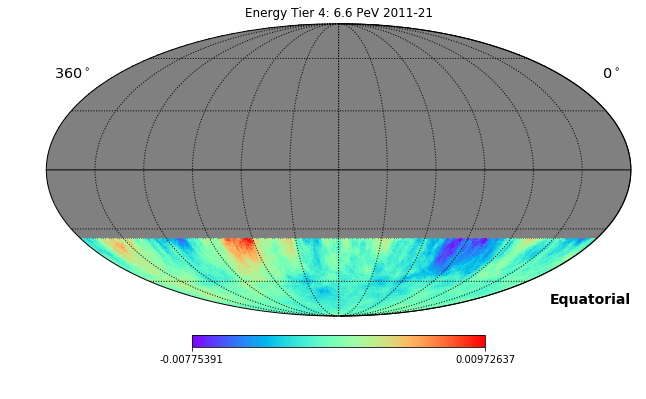

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


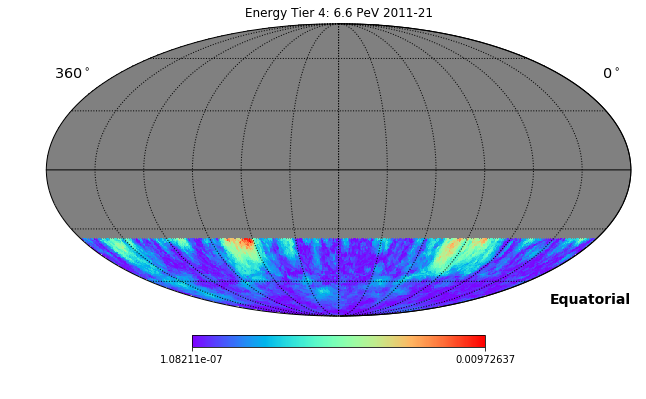

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


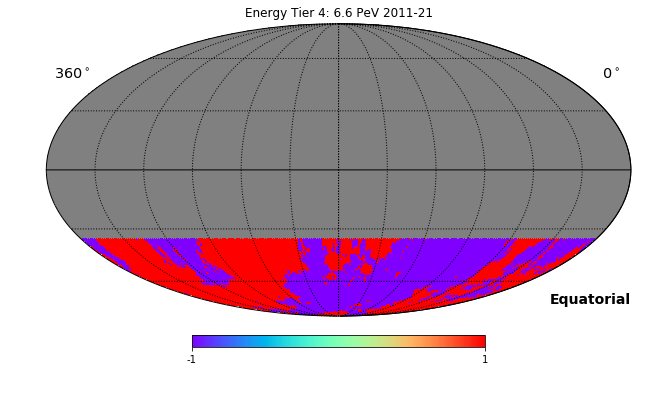

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


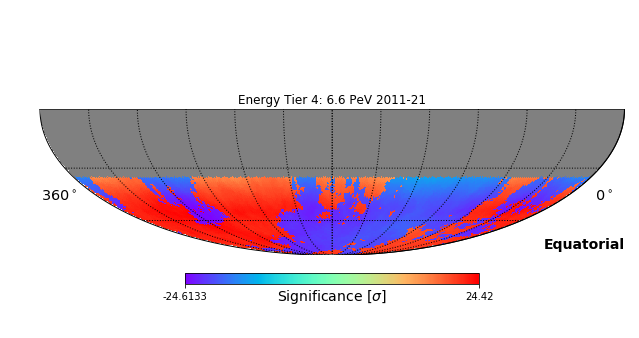

In [18]:
#JUAN CARLOS
#Significance- mask then smooth
rel_int = data/bg - 1
masked_combined = maskMap(rel_int, decMin, decMax)
masked_variance = maskMap(sig, decMin, decMax)

#Do np.abs on masked array to avoid taking the absolute value of hp.UNSEEN/dividing out hp.UNSEEN
num = TopHatSmooth(nside,masked_combined,radius=radius_smooth,average=True)
plot_map(num, Title)

"""
abs_rel_int = np.abs(rel_int)
masked_denom = maskMap(abs_rel_int, decMin, decMax)
plot_map(masked_denom, Title)
denom = TopHatSmooth(nside,masked_denom,radius=radius_smooth,average=True)
plot_map(denom, Title)
"""
denom = np.abs(hp.ma(num))
plot_map(denom.filled(fill_value=hp.UNSEEN), Title)

masked_np_num = hp.ma(num)
masked_np_denom = hp.ma(denom)
neg = masked_np_num / masked_np_denom
plot_map(neg, Title)

variance_smooth = TopHatSmooth(nside, masked_variance, radius=radius_smooth, average=False) 
masked_np_variance_smooth = hp.ma(variance_smooth)
significance_llh_iter20 = np.sqrt(np.abs(masked_np_variance_smooth))

#this makes sure that the significance has the right value and sign
signed_significance = significance_llh_iter20 * neg
signed_significance.filled(fill_value=hp.UNSEEN)
plot_map(signed_significance, Title, 
         label='Significance [$\sigma$]', half_map=True)

In [18]:
def smoothMap(m, wtsqr=False, norm=False, smooth_rad=0):

    if wtsqr==True:
        return None

    npix  = len(m)
    nside = hp.npix2nside(npix)
    #smooth_rad = opts['smooth'] * pi/180.
    smooth_map = np.zeros(npix)

    vec = np.transpose(hp.pix2vec(nside, np.arange(npix)))
    for i in range(npix):
        neighbors = hp.query_disc(nside, vec[i], smooth_rad)
        smooth_map[i] += m[neighbors].sum()
        if norm:
            smooth_map[i] /= (len(neighbors) + 1)

    return smooth_map

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


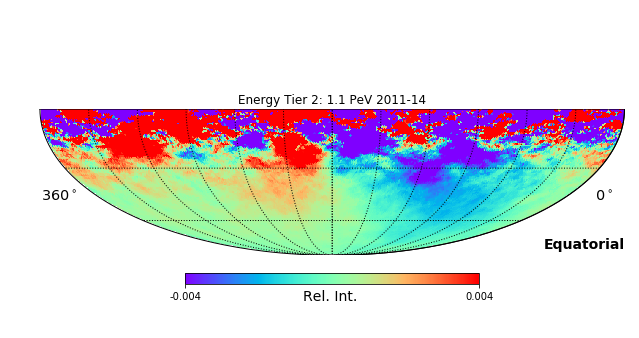

In [22]:
#FRANKS METHOD
data_smooth = smoothMap(data, smooth_rad=radius_smooth)
bg_smooth = smoothMap(bg, smooth_rad=radius_smooth)
m = (data_smooth - bg_smooth) / bg_smooth
m[np.isnan(m)] = 0
m = maskMap(m, decMin, decMax)

plot_map(m, Title, label="Rel. Int. ", half_map=True, dMin = -.004, dMax = .004)

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


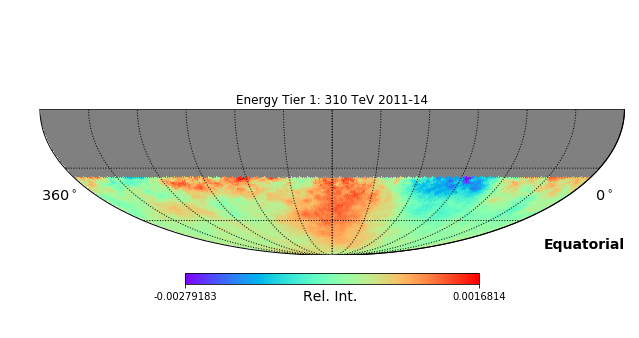

In [8]:
#My version of frank's version (gets same output)

data_smooth = TopHatSmooth(nside, data, radius_smooth, average=True)
bg_smooth = TopHatSmooth(nside, bg, radius_smooth, average=True)
ri = data_smooth - bg_smooth
ri_mask = maskMap(ri, decMin, decMax)
bg_mask = maskMap(bg_smooth, decMin, decMax)
masked_ri_a = hp.ma(ri_mask)
masked_bg_a = hp.ma(bg_mask)
ri_p = masked_ri_a / masked_bg_a
ri_p.filled(fill_value=hp.UNSEEN)

plot_map(ri_p, Title, label='Rel. Int. ', half_map = True) #, dMin = -.003, dMax = .003,         filename="/home/gagrawal/skymaps/output/ts_meth/et4_ri.png")

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


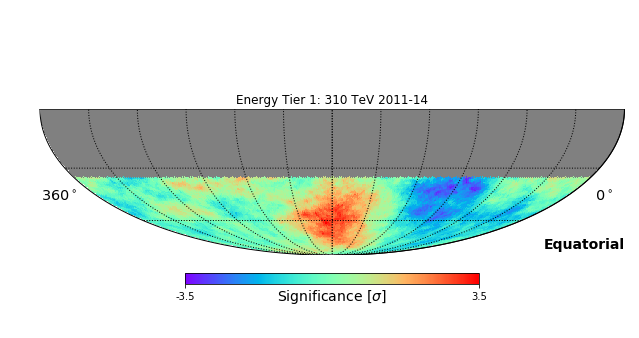

In [14]:
#SIGNIFICANCE

#FRANKS METHOD
data_smooth = smoothMap(data, smooth_rad=radius_smooth)
bg_smooth = smoothMap(bg, smooth_rad=radius_smooth)

with np.errstate(invalid='ignore', divide='ignore'):
    #alpha = 1/20.
    alpha = 1.
    # Allow for scaling term if weighted square maps necessary
    scale = 1.
    Non  = data_smooth * scale
    Noff = bg_smooth/alpha * scale

    sn = np.sign(data_smooth - bg_smooth)
    sigma = sn * sqrt(2*(Non*np.log(((1+alpha)*Non) / (alpha*(Non+Noff)))
                         + Noff * np.log(((1+alpha)*Noff) / (Non+Noff))))

sigma[np.isnan(sigma)] = 0
sigma_masked = maskMap(sigma, decMin, decMax)
plot_map(sigma_masked, Title, label='Significance [$\sigma$]', half_map=True, dMin=-3.5, dMax=3.5)

In [ ]:
#FRANKS CODE

In [ ]:
#Relative Intensity

#Mask then smooth
masked_map = maskMap(combined_llh_iter01, decMin, decMax)
smoothed_map = TopHatSmooth(nside, masked_map, radius_smooth, average=True)


plot_map(masked_map, Title, label='Rel. Int. Raw', half_map = True, dMin = -.05, dMax = .05)
plot_map(smoothed_map, Title, label='Rel. Int. ', half_map = True) 

In [ ]:
#FEB 2024 CODE

In [ ]:
#Relative Intensity

#Mask then smooth
masked_map = maskMap(combined_llh_iter20, decMin, decMax)
smoothed_map = TopHatSmooth(nside, masked_map, radius_smooth, average=True)
plot_map(smoothed_map, Title, label='Rel. Int. ', half_map = True) 

In [ ]:
#Plot with specificed range and save
plot_map(smoothed_map, Title, label='Rel. Int. ', half_map = True, dMin = -.012, dMax = .012, filename="/home/gagrawal/skymaps/output/et2_ri.png")

In [ ]:
#Significance- mask then smooth

masked_combined = maskMap(combined_llh_iter20, decMin, decMax)
masked_variance = maskMap(variance_llh_iter20, decMin, decMax)


#Do np.abs on masked array to avoid taking the absolute value of hp.UNSEEN/dividing out hp.UNSEEN
num = TopHatSmooth(nside,masked_combined,radius=radius_smooth,average=True)

masked_np_combined = hp.ma(masked_combined)
denom = TopHatSmooth(nside,np.abs(masked_np_combined).filled(fill_value=hp.UNSEEN),radius=radius_smooth,average=True)

masked_np_num = hp.ma(num)
masked_np_denom = hp.ma(denom)
neg = masked_np_num / masked_np_denom

variance_smooth = TopHatSmooth(nside, masked_variance, radius=radius_smooth, average=False) #Why is average false?
masked_np_variance_smooth = hp.ma(variance_smooth)
significance_llh_iter20 = np.sqrt(np.abs(masked_np_variance_smooth))

#this makes sure that the significance has the right value and sign
signed_significance = significance_llh_iter20 * neg

plot_map(signed_significance.filled(fill_value=hp.UNSEEN), Title, 
         label='Significance [$\sigma$]', half_map=True) 

In [ ]:
#Plot with specified range and save to directory
plot_map(signed_significance.filled(fill_value=hp.UNSEEN), Title, 
         label='Significance [$\sigma$]', half_map=True, dMin=-6, dMax=6, filename="/home/gagrawal/skymaps/output/et2_sig.png")

In [ ]:
#Relative Intensity - OG

#Smooth then mask
smoothed_map = TopHatSmooth(64,combined_llh_iter20,radius_smooth,average=True)

plot_map(smoothed_map, Title, label='Rel. Int. [$\sigma$]') #,dMin=-0.003, dMax=0.003)

masked_map = maskMap(smoothed_map, decMin, decMax)

plot_map(masked_map, Title, label='Rel. Int. [$\sigma$]', half_map = True) #,dMin=-0.003, dMax=0.003)

In [21]:
#Significance Skymap Calculation - OG

neg = TopHatSmooth(64,combined_llh_iter20,radius=smoothAngle*degree,average=True)/TopHatSmooth(64,np.abs(combined_llh_iter20),radius=5.0*degree,average=True)

#used to find the value of the significance, the maskMap 
variance_llh_smooth_iter20 = TopHatSmooth(64,variance_llh_iter20,radius=smoothAngle*degree, average=False)
significance_llh_iter20 = np.sqrt(np.abs(variance_llh_smooth_iter20))

#this makes sure that the significance has the right value and sign
signed_significance = significance_llh_iter20 * neg
masked_map = maskMap(signed_significance, decMin, decMax)

plot_map(masked_map, Title, label='Significance [$\sigma$]', half_map = True) #, dMin=-8, dMax=8)

KeyboardInterrupt: 